In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )
else:
    print("No GPU detected.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4
VRAM: 22.03 GB


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Detection"

print(os.listdir(PROJECT_DIR))

['raw_dataset.zip', 'splits', 'best_efficientnet_b0.pth']


In [4]:
import zipfile
import os

ZIP_PATH = os.path.join(PROJECT_DIR, "raw_dataset.zip")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    files = zip_ref.namelist()

print("Total files:", len(files))

print("\nFirst 30 files:")
for file in files[:30]:
    print(file)

Total files: 12891

First 30 files:
Final Dataset/Fake/001DDU0NI4.jpg
Final Dataset/Fake/002KDWZBHU.jpg
Final Dataset/Fake/002PMM0QG9.jpg
Final Dataset/Fake/002TJAKUYX.jpg
Final Dataset/Fake/003IRD4LS5.jpg
Final Dataset/Fake/00A0WLZE5X.jpg
Final Dataset/Fake/00AUP94LQS.jpg
Final Dataset/Fake/00B4R41FLE.jpg
Final Dataset/Fake/00C64W8TYZ.jpg
Final Dataset/Fake/00CB415UQ7.jpg
Final Dataset/Fake/00ELJIYESN.jpg
Final Dataset/Fake/00ELSET7NI.jpg
Final Dataset/Fake/00G7CTY1FF.jpg
Final Dataset/Fake/00GO3W8WCY.jpg
Final Dataset/Fake/00GYML2PNL.jpg
Final Dataset/Fake/00HZSJQ99D.jpg
Final Dataset/Fake/00JC8ESFO5.jpg
Final Dataset/Fake/00M23E4K4I.jpg
Final Dataset/Fake/00NDQUECJA.jpg
Final Dataset/Fake/00NEVKRNFZ.jpg
Final Dataset/Fake/00NVFY3Y64.jpg
Final Dataset/Fake/00NZWX01HF.jpg
Final Dataset/Fake/00ONA5N3VR.jpg
Final Dataset/Fake/00P2LUXJW3.jpg
Final Dataset/Fake/00PYA83V1P.jpg
Final Dataset/Fake/00QZ9OQ733.jpg
Final Dataset/Fake/00S2D5CDKQ.jpg
Final Dataset/Fake/00TMYXA5DF.jpg
Final Datase

In [5]:
from collections import Counter
import zipfile
import os

ZIP_PATH = os.path.join(PROJECT_DIR, "raw_dataset.zip")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    files = zip_ref.namelist()

# Count image files by class
fake_count = sum(
    1 for f in files
    if "/Fake/" in f and f.lower().endswith((".jpg", ".jpeg", ".png"))
)

real_count = sum(
    1 for f in files
    if "/Real/" in f and f.lower().endswith((".jpg", ".jpeg", ".png"))
)

print("Fake images :", fake_count)
print("Real images :", real_count)
print("Total images:", fake_count + real_count)

print("\nOther files:")
other_files = [
    f for f in files
    if not f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for f in other_files[:20]:
    print(f)

Fake images : 7000
Real images : 5890
Total images: 12890

Other files:
Final Dataset/dataset.csv


In [6]:
import zipfile
import pandas as pd
import os
import io

ZIP_PATH = os.path.join(PROJECT_DIR, "raw_dataset.zip")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    csv_path = "Final Dataset/dataset.csv"

    with zip_ref.open(csv_path) as f:
        df = pd.read_csv(f)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

print("\nData types:")
print(df.dtypes)

Shape: (12890, 2)

Columns:
['path', 'label']

First 10 rows:


,path,label
0,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
1,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
2,/kaggle/input/stylegan-and-stylegan2-combined-...,Fake
3,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
4,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
5,/kaggle/input/stylegan-and-stylegan2-combined-...,Fake
6,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
7,/kaggle/input/stylegan-and-stylegan2-combined-...,Fake
8,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
9,/kaggle/input/stylegan-and-stylegan2-combined-...,Real



Data types:
path     object
label    object
dtype: object


In [7]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nUnique values:")
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


Missing values:
path     0
label    0
dtype: int64

Unique values:

path:
['/kaggle/input/stylegan-and-stylegan2-combined-dataset/Final Dataset/Real/real_378_aug_1.jpg'
 '/kaggle/input/stylegan-and-stylegan2-combined-dataset/Final Dataset/Real/real_283_aug_1.jpg'
 '/kaggle/input/stylegan-and-stylegan2-combined-dataset/Final Dataset/Fake/2TSVE42PCX.jpg'
 '/kaggle/input/stylegan-and-stylegan2-combined-dataset/Final Dataset/Real/real_213_aug_3.jpg'
 '/kaggle/input/stylegan-and-stylegan2-combined-dataset/Final Dataset/Real/01149.jpg'
 '/kaggle/input/stylegan-and-stylegan2-combined-dataset/Final Dataset/Fake/0KB5700VPB.jpg'
 '/kaggle/input/stylegan-and-stylegan2-combined-dataset/Final Dataset/Real/02450.jpg'
 '/kaggle/input/stylegan-and-stylegan2-combined-dataset/Final Dataset/Fake/1VZRWOCVTF.jpg'
 '/kaggle/input/stylegan-and-stylegan2-combined-dataset/Final Dataset/Real/real_127_aug_0.jpg'
 '/kaggle/input/stylegan-and-stylegan2-combined-dataset/Final Dataset/Real/03700.jpg'
 '/kaggle/inpu

In [8]:
import pandas as pd
import re

# Class distribution
print("CLASS DISTRIBUTION")
print(df["label"].value_counts())
print("\nPercentage:")
print((df["label"].value_counts(normalize=True) * 100).round(2))


# Analyze augmented filenames
df["filename"] = df["path"].str.split("/").str[-1]

df["is_augmented"] = df["filename"].str.contains(
    r"_aug_\d+",
    regex=True
)

print("\nAUGMENTATION DISTRIBUTION")
print(df.groupby(["label", "is_augmented"]).size())


print("\nAugmented images:")
print(df["is_augmented"].value_counts())

CLASS DISTRIBUTION
label
Fake    7000
Real    5890
Name: count, dtype: int64

Percentage:
label
Fake    54.31
Real    45.69
Name: proportion, dtype: float64

AUGMENTATION DISTRIBUTION
label  is_augmented
Fake   False           3500
       True            3500
Real   False           2945
       True            2945
dtype: int64

Augmented images:
is_augmented
True     6445
False    6445
Name: count, dtype: int64


In [9]:
# Show examples of augmented files

augmented = df[df["is_augmented"]]

print("Number of augmented images:", len(augmented))

display(
    augmented[["filename", "label"]]
    .head(30)
)

Number of augmented images: 6445


,filename,label
0,real_378_aug_1.jpg,Real
1,real_283_aug_1.jpg,Real
3,real_213_aug_3.jpg,Real
8,real_127_aug_0.jpg,Real
10,fake_273_aug_2.jpg,Fake
12,real_545_aug_1.jpg,Real
13,fake_530_aug_1.jpg,Fake
15,fake_638_aug_1.jpg,Fake
16,fake_33_aug_2.jpg,Fake
17,real_36_aug_4.jpg,Real


In [10]:
def get_base_name(filename):
    return re.sub(r"_aug_\d+(?=\.[^.]+$)", "", filename)

df["base_name"] = df["filename"].apply(get_base_name)

print("Unique underlying filenames:")
print(df["base_name"].nunique())

print("\nImages per underlying filename:")
print(df.groupby("base_name").size().value_counts().sort_index())

Unique underlying filenames:
7734

Images per underlying filename:
1    6445
5    1289
Name: count, dtype: int64


In [11]:
print("\nExamples with multiple versions:")

group_sizes = df.groupby("base_name").size()

multi = group_sizes[group_sizes > 1].index

display(
    df[df["base_name"].isin(multi)]
    [["filename", "base_name", "label"]]
    .head(50)
)


Examples with multiple versions:


,filename,base_name,label
0,real_378_aug_1.jpg,real_378.jpg,Real
1,real_283_aug_1.jpg,real_283.jpg,Real
3,real_213_aug_3.jpg,real_213.jpg,Real
8,real_127_aug_0.jpg,real_127.jpg,Real
10,fake_273_aug_2.jpg,fake_273.jpg,Fake
12,real_545_aug_1.jpg,real_545.jpg,Real
13,fake_530_aug_1.jpg,fake_530.jpg,Fake
15,fake_638_aug_1.jpg,fake_638.jpg,Fake
16,fake_33_aug_2.jpg,fake_33.jpg,Fake
17,real_36_aug_4.jpg,real_36.jpg,Real


In [12]:
import os
import zipfile
import shutil

ZIP_PATH = "/content/drive/MyDrive/Deepfake_Detection/raw_dataset.zip"
EXTRACT_DIR = "/content/deepfake_dataset"

# Remove previous extraction if it exists
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Extracting dataset...")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction complete!")

Extracting dataset...
Extraction complete!


In [13]:
import os

for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

    for file in files[:5]:
        print(f"{indent}    {file}")

deepfake_dataset/
    Final Dataset/
        dataset.csv
        Fake/
        Real/


In [14]:
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

FAKE_DIR = os.path.join(
    EXTRACT_DIR,
    "Final Dataset",
    "Fake"
)

REAL_DIR = os.path.join(
    EXTRACT_DIR,
    "Final Dataset",
    "Real"
)

fake_images = [
    os.path.join(FAKE_DIR, f)
    for f in os.listdir(FAKE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

real_images = [
    os.path.join(REAL_DIR, f)
    for f in os.listdir(REAL_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Fake:", len(fake_images))
print("Real:", len(real_images))

Fake: 7000
Real: 5890


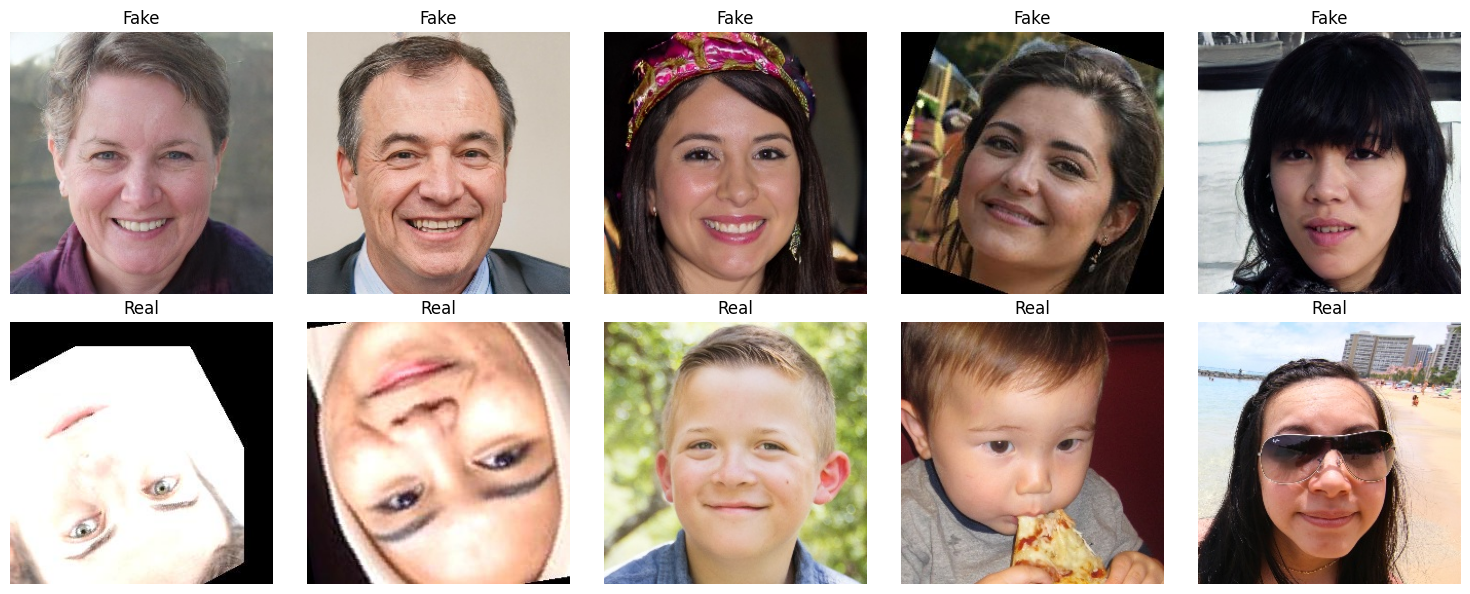

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    fake_path = random.choice(fake_images)
    real_path = random.choice(real_images)

    fake_img = Image.open(fake_path)
    real_img = Image.open(real_path)

    axes[0, i].imshow(fake_img)
    axes[0, i].set_title("Fake")
    axes[0, i].axis("off")

    axes[1, i].imshow(real_img)
    axes[1, i].set_title("Real")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [16]:
from PIL import Image
import os
from collections import Counter
import pandas as pd

def inspect_images(image_paths):
    records = []
    corrupt = []

    for path in image_paths:
        try:
            with Image.open(path) as img:
                records.append({
                    "path": path,
                    "width": img.width,
                    "height": img.height,
                    "mode": img.mode,
                    "format": img.format,
                    "aspect_ratio": round(img.width / img.height, 3)
                })
        except Exception as e:
            corrupt.append((path, str(e)))

    return pd.DataFrame(records), corrupt


fake_df, fake_corrupt = inspect_images(fake_images)
real_df, real_corrupt = inspect_images(real_images)

fake_df["label"] = "Fake"
real_df["label"] = "Real"

image_df = pd.concat([fake_df, real_df], ignore_index=True)

print("Total successfully inspected:", len(image_df))
print("Corrupt Fake images:", len(fake_corrupt))
print("Corrupt Real images:", len(real_corrupt))

Total successfully inspected: 12890
Corrupt Fake images: 0
Corrupt Real images: 0


In [17]:
print("\nIMAGE MODES")
print(pd.crosstab(image_df["label"], image_df["mode"]))

print("\nIMAGE FORMATS")
print(pd.crosstab(image_df["label"], image_df["format"]))

print("\nCOMMON DIMENSIONS")
print(
    image_df.groupby(["label", "width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(20)
)


IMAGE MODES
mode    RGB
label      
Fake   7000
Real   5890

IMAGE FORMATS
format  JPEG
label       
Fake    7000
Real    5890

COMMON DIMENSIONS
label  width  height
Fake   256    256       3561
Real   256    256       2997
Fake   300    300        905
Real   300    300        753
Fake   272    272         76
       280    280         76
       298    298         70
       284    284         68
Real   260    260         68
Fake   270    270         68
       250    250         67
       268    268         67
       292    292         65
       296    296         64
       274    274         64
       288    288         64
       244    244         63
Real   262    262         63
       292    292         62
       282    282         61
dtype: int64


In [18]:
print("\nDIMENSION SUMMARY")

display(
    image_df.groupby("label")[["width", "height", "aspect_ratio"]]
    .agg(["min", "max", "mean", "median"])
)


DIMENSION SUMMARY


width                         height                          \
        min  max        mean median    min  max        mean median   
label                                                                
Fake    196  360  270.565143  256.0    196  360  270.565143  256.0   
Real    196  360  270.674703  256.0    196  360  270.674703  256.0   

      aspect_ratio                   
               min  max mean median  
label                                
Fake           1.0  1.0  1.0    1.0  
Real           1.0  1.0  1.0    1.0

In [19]:
from PIL import Image
import os

def get_exif_orientation(path):
    try:
        with Image.open(path) as img:
            exif = img.getexif()
            return exif.get(274, None)  # EXIF Orientation tag
    except:
        return None

image_df["exif_orientation"] = image_df["path"].apply(
    get_exif_orientation
)

print(pd.crosstab(
    image_df["label"],
    image_df["exif_orientation"],
    dropna=False
))

exif_orientation   NaN
label                 
Fake              7000
Real              5890


In [20]:
import hashlib
from collections import defaultdict
import os

def md5_file(path, chunk_size=8192):
    md5 = hashlib.md5()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)

            if not chunk:
                break

            md5.update(chunk)

    return md5.hexdigest()


hash_to_files = defaultdict(list)

all_images = fake_images + real_images

print("Calculating image hashes...")

for i, path in enumerate(all_images):
    file_hash = md5_file(path)
    hash_to_files[file_hash].append(path)

    if (i + 1) % 1000 == 0:
        print(f"Processed {i + 1}/{len(all_images)}")

duplicate_groups = {
    h: paths
    for h, paths in hash_to_files.items()
    if len(paths) > 1
}

print("\nUnique hashes:", len(hash_to_files))
print("Duplicate groups:", len(duplicate_groups))

duplicate_images = sum(
    len(paths) for paths in duplicate_groups.values()
)

print("Images involved in duplicate groups:", duplicate_images)

Calculating image hashes...
Processed 1000/12890
Processed 2000/12890
Processed 3000/12890
Processed 4000/12890
Processed 5000/12890
Processed 6000/12890
Processed 7000/12890
Processed 8000/12890
Processed 9000/12890
Processed 10000/12890
Processed 11000/12890
Processed 12000/12890

Unique hashes: 12886
Duplicate groups: 4
Images involved in duplicate groups: 8


In [21]:
print("\nExample duplicate groups:")

for i, (file_hash, paths) in enumerate(duplicate_groups.items()):

    print(f"\nGroup {i + 1}:")

    for path in paths:
        print(" ", os.path.basename(path))

    if i >= 9:
        break


Example duplicate groups:

Group 1:
  fake_104_aug_1.jpg
  fake_104_aug_0.jpg

Group 2:
  fake_484_aug_2.jpg
  fake_484_aug_1.jpg

Group 3:
  real_271_aug_1.jpg
  real_271_aug_0.jpg

Group 4:
  real_216_aug_3.jpg
  real_216_aug_2.jpg


In [22]:
# Check whether any base image appears with multiple labels

label_counts = df.groupby("base_name")["label"].nunique()

conflicting_groups = label_counts[label_counts > 1]

print("Total groups:", len(label_counts))
print("Groups with conflicting labels:", len(conflicting_groups))

if len(conflicting_groups) > 0:
    print("\nWARNING: Conflicting groups found:")
    print(conflicting_groups)
else:
    print("✅ Every image group has exactly one label.")

Total groups: 7734
Groups with conflicting labels: 0
✅ Every image group has exactly one label.


In [23]:
group_df = (
    df.groupby("base_name")
      .agg(
          label=("label", "first"),
          group_size=("filename", "count")
      )
      .reset_index()
)

print("Number of groups:", len(group_df))

print("\nGroups by label:")
print(group_df["label"].value_counts())

print("\nGroup sizes:")
print(group_df["group_size"].value_counts().sort_index())

Number of groups: 7734

Groups by label:
label
Fake    4200
Real    3534
Name: count, dtype: int64

Group sizes:
group_size
1    6445
5    1289
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import train_test_split

# First split:
# 70% train
# 30% temporary (validation + test)

train_groups, temp_groups = train_test_split(
    group_df,
    test_size=0.30,
    random_state=42,
    stratify=group_df["label"]
)

# Second split:
# 15% validation
# 15% test

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    random_state=42,
    stratify=temp_groups["label"]
)

print("Train groups:", len(train_groups))
print("Validation groups:", len(val_groups))
print("Test groups:", len(test_groups))

Train groups: 5413
Validation groups: 1160
Test groups: 1161


In [25]:
train_base_names = set(train_groups["base_name"])
val_base_names = set(val_groups["base_name"])
test_base_names = set(test_groups["base_name"])

def assign_split(base_name):
    if base_name in train_base_names:
        return "train"
    elif base_name in val_base_names:
        return "val"
    elif base_name in test_base_names:
        return "test"
    else:
        return None

df["split"] = df["base_name"].apply(assign_split)

print(df["split"].value_counts())

split
train    9085
test     1905
val      1900
Name: count, dtype: int64


In [26]:
train_set = set(
    df[df["split"] == "train"]["base_name"]
)

val_set = set(
    df[df["split"] == "val"]["base_name"]
)

test_set = set(
    df[df["split"] == "test"]["base_name"]
)

print("Train ∩ Validation:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Validation ∩ Test:", len(val_set & test_set))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [27]:
print("\nIMAGE COUNTS")
print(
    pd.crosstab(
        df["split"],
        df["label"]
    )
)

print("\nPERCENTAGES")
print(
    pd.crosstab(
        df["split"],
        df["label"],
        normalize="index"
    ).round(4) * 100
)


IMAGE COUNTS
label  Fake  Real
split            
test   1006   899
train  4980  4105
val    1014   886

PERCENTAGES
label   Fake   Real
split              
test   52.81  47.19
train  54.82  45.18
val    53.37  46.63


In [28]:
SPLIT_DIR = "/content/drive/MyDrive/Deepfake_Detection/splits"

os.makedirs(SPLIT_DIR, exist_ok=True)

df[
    ["path", "filename", "base_name", "label", "split"]
].to_csv(
    os.path.join(SPLIT_DIR, "dataset_split.csv"),
    index=False
)

print("Saved:", os.path.join(SPLIT_DIR, "dataset_split.csv"))

Saved: /content/drive/MyDrive/Deepfake_Detection/splits/dataset_split.csv


In [29]:
import os
import pandas as pd

SPLIT_CSV = "/content/drive/MyDrive/Deepfake_Detection/splits/dataset_split.csv"

df = pd.read_csv(SPLIT_CSV)

DATASET_ROOT = "/content/deepfake_dataset/Final Dataset"

df["local_path"] = df.apply(
    lambda row: os.path.join(
        DATASET_ROOT,
        row["label"],
        row["filename"]
    ),
    axis=1
)

print(df[["filename", "label", "split", "local_path"]].head())

             filename label  split  \
0  real_378_aug_1.jpg  Real  train   
1  real_283_aug_1.jpg  Real  train   
2      2TSVE42PCX.jpg  Fake   test   
3  real_213_aug_3.jpg  Real    val   
4           01149.jpg  Real  train   

                                          local_path  
0  /content/deepfake_dataset/Final Dataset/Real/r...  
1  /content/deepfake_dataset/Final Dataset/Real/r...  
2  /content/deepfake_dataset/Final Dataset/Fake/2...  
3  /content/deepfake_dataset/Final Dataset/Real/r...  
4  /content/deepfake_dataset/Final Dataset/Real/0...  


In [30]:
print(
    "Missing files:",
    (~df["local_path"].apply(os.path.exists)).sum()
)

Missing files: 0


In [31]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class DeepfakeDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

        self.label_map = {
            "Real": 0,
            "Fake": 1
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):

        row = self.data.iloc[index]

        image = Image.open(row["local_path"]).convert("RGB")

        label = self.label_map[row["label"]]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [32]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [33]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [34]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

train_dataset = DeepfakeDataset(
    train_df,
    transform=train_transform
)

val_dataset = DeepfakeDataset(
    val_df,
    transform=eval_transform
)

test_dataset = DeepfakeDataset(
    test_df,
    transform=eval_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 9085
Validation: 1900
Test: 1905


In [35]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [36]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:20])
print("Image dtype:", images.dtype)

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
Labels: tensor([0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0])
Image dtype: torch.float32


In [37]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

Device: cuda
GPU: NVIDIA L4
VRAM: 22.03 GB


In [38]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Load pretrained EfficientNet-B0
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [39]:
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

In [40]:
model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [41]:
criterion = nn.CrossEntropyLoss()

In [42]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [43]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [44]:
scaler = torch.amp.GradScaler("cuda")

In [45]:
model.train()

images, labels = next(iter(train_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

optimizer.zero_grad(set_to_none=True)

with torch.autocast(device_type="cuda", dtype=torch.float16):
    outputs = model(images)
    loss = criterion(outputs, labels)

scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()

print("Forward + backward test successful!")
print("Output shape:", outputs.shape)
print("Loss:", loss.item())

Forward + backward test successful!
Output shape: torch.Size([64, 2])
Loss: 0.7107505798339844


In [46]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

EPOCHS = 10

best_val_loss = float("inf")
best_model_path = "/content/drive/MyDrive/Deepfake_Detection/best_efficientnet_b0.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

for epoch in range(EPOCHS):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_train_loss = 0.0
    train_samples = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)

        running_train_loss += loss.item() * batch_size
        train_samples += batch_size

    train_loss = running_train_loss / train_samples


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    running_val_loss = 0.0
    val_samples = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.autocast(device_type="cuda", dtype=torch.float16):

                outputs = model(images)

                loss = criterion(outputs, labels)

            predictions = torch.argmax(outputs, dim=1)

            batch_size = images.size(0)

            running_val_loss += loss.item() * batch_size
            val_samples += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    val_loss = running_val_loss / val_samples

    val_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    val_precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    val_recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    val_f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )


    # =========================
    # LEARNING RATE SCHEDULER
    # =========================
    scheduler.step(val_loss)


    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "val_f1": val_f1
        }, best_model_path)

        best_marker = " ⭐ BEST"

    else:
        best_marker = ""


    # =========================
    # STORE HISTORY
    # =========================
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["val_precision"].append(val_precision)
    history["val_recall"].append(val_recall)
    history["val_f1"].append(val_f1)


    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"LR: {current_lr:.2e}"
        f"{best_marker}"
    )

Epoch [1/10] | Train Loss: 0.3315 | Val Loss: 0.1998 | Val Acc: 0.9153 | Val F1: 0.9225 | LR: 1.00e-04 ⭐ BEST
Epoch [2/10] | Train Loss: 0.1525 | Val Loss: 0.1251 | Val Acc: 0.9500 | Val F1: 0.9540 | LR: 1.00e-04 ⭐ BEST
Epoch [3/10] | Train Loss: 0.0937 | Val Loss: 0.1214 | Val Acc: 0.9521 | Val F1: 0.9566 | LR: 1.00e-04 ⭐ BEST
Epoch [4/10] | Train Loss: 0.0627 | Val Loss: 0.1046 | Val Acc: 0.9658 | Val F1: 0.9683 | LR: 1.00e-04 ⭐ BEST
Epoch [5/10] | Train Loss: 0.0524 | Val Loss: 0.1145 | Val Acc: 0.9637 | Val F1: 0.9667 | LR: 1.00e-04
Epoch [6/10] | Train Loss: 0.0403 | Val Loss: 0.0844 | Val Acc: 0.9737 | Val F1: 0.9755 | LR: 1.00e-04 ⭐ BEST
Epoch [7/10] | Train Loss: 0.0339 | Val Loss: 0.1076 | Val Acc: 0.9637 | Val F1: 0.9669 | LR: 1.00e-04
Epoch [8/10] | Train Loss: 0.0332 | Val Loss: 0.0795 | Val Acc: 0.9716 | Val F1: 0.9734 | LR: 1.00e-04 ⭐ BEST
Epoch [9/10] | Train Loss: 0.0246 | Val Loss: 0.0870 | Val Acc: 0.9747 | Val F1: 0.9767 | LR: 1.00e-04
Epoch [10/10] | Train Loss: 0.0

In [47]:
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load best checkpoint
checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

print("Best checkpoint loaded.")
print("Checkpoint epoch:", checkpoint["epoch"])
print("Checkpoint validation loss:", checkpoint["val_loss"])
print("Checkpoint validation accuracy:", checkpoint["val_accuracy"])
print("Checkpoint validation F1:", checkpoint["val_f1"])

Best checkpoint loaded.
Checkpoint epoch: 10
Checkpoint validation loss: 0.07798875198552482
Checkpoint validation accuracy: 0.9794736842105263
Checkpoint validation F1: 0.9807597434632461


In [48]:
model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(
            probabilities[:, 1].float().cpu().numpy()
        )

# Metrics
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

test_auc = roc_auc_score(
    all_labels,
    all_probabilities
)

print("\n===== TEST RESULTS =====")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Real", "Fake"],
        digits=4
    )
)

print("\n===== CONFUSION MATRIX =====")
print(
    confusion_matrix(
        all_labels,
        all_predictions
    )
)


===== TEST RESULTS =====
Accuracy : 0.9774
Precision: 0.9763
Recall   : 0.9811
F1 Score : 0.9787
ROC-AUC  : 0.9971

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        Real     0.9787    0.9733    0.9760       899
        Fake     0.9763    0.9811    0.9787      1006

    accuracy                         0.9774      1905
   macro avg     0.9775    0.9772    0.9773      1905
weighted avg     0.9774    0.9774    0.9774      1905


===== CONFUSION MATRIX =====
[[875  24]
 [ 19 987]]


<Figure size 700x600 with 0 Axes>

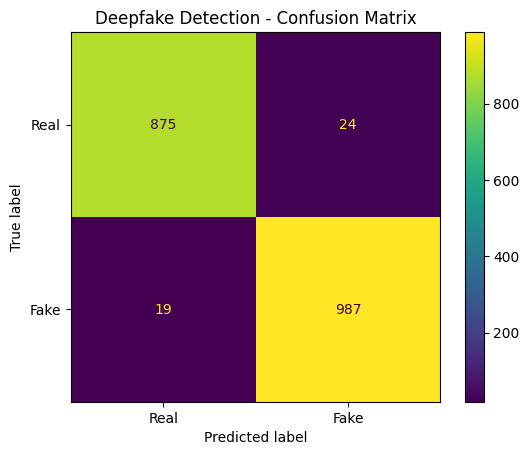

<Figure size 700x600 with 0 Axes>

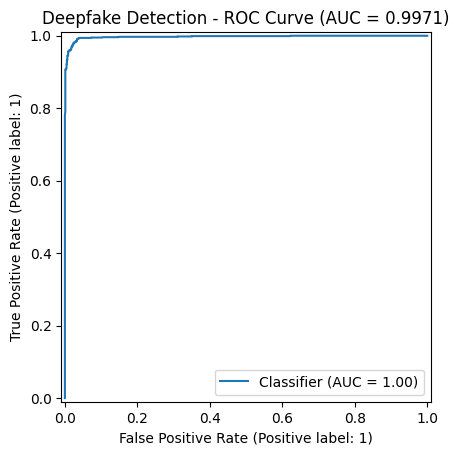

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot(values_format="d")

plt.title("Deepfake Detection - Confusion Matrix")
plt.show()


# =========================
# ROC CURVE
# =========================

plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    all_labels,
    all_probabilities
)

plt.title(
    f"Deepfake Detection - ROC Curve "
    f"(AUC = {test_auc:.4f})"
)

plt.show()

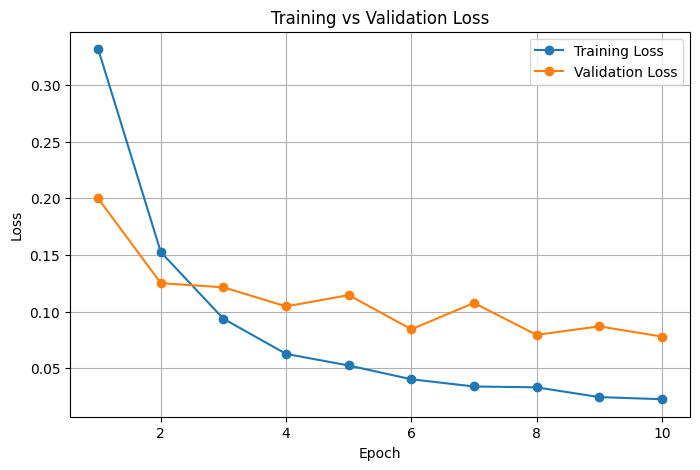

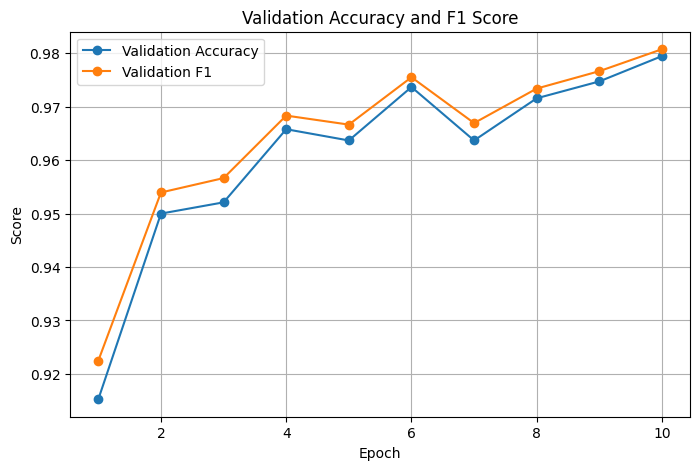

In [50]:
epochs = range(1, len(history["train_loss"]) + 1)

# =========================
# LOSS CURVE
# =========================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# METRICS CURVE
# =========================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    epochs,
    history["val_f1"],
    marker="o",
    label="Validation F1")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Accuracy and F1 Score")
plt.legend()
plt.grid(True)
plt.show()

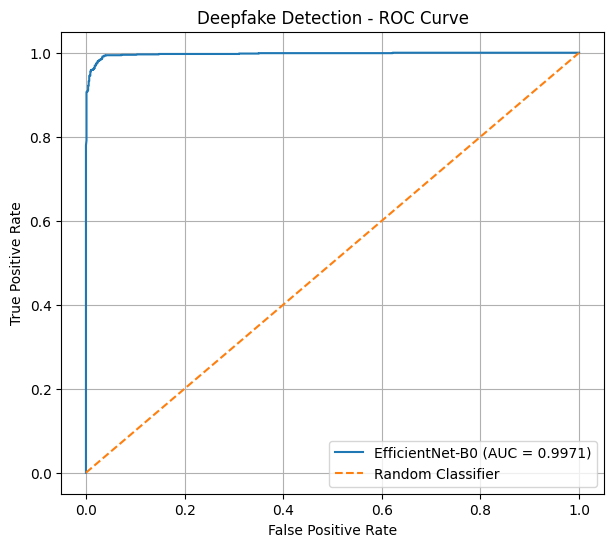

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probabilities
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"EfficientNet-B0 (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Deepfake Detection - ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
import pandas as pd

SPLIT_CSV = "/content/drive/MyDrive/Deepfake_Detection/splits/dataset_split.csv"

split_df = pd.read_csv(SPLIT_CSV)

print("Columns:")
print(split_df.columns.tolist())

print("\nShape:")
print(split_df.shape)

print("\nSplit distribution:")
print(split_df["split"].value_counts())

print("\nTest rows:")
print(len(split_df[split_df["split"] == "test"]))

Columns:
['path', 'filename', 'base_name', 'label', 'split']

Shape:
(12890, 5)

Split distribution:
split
train    9085
test     1905
val      1900
Name: count, dtype: int64

Test rows:
1905


In [53]:
# Get the test portion of the split metadata
test_df = split_df[split_df["split"] == "test"].copy().reset_index(drop=True)

# Create prediction results
test_results = test_df[[
    "path",
    "filename",
    "base_name",
    "label"
]].copy()

# Convert numeric labels back to class names
label_names = {
    0: "Real",
    1: "Fake"
}

test_results["true_label"] = [
    label_names[x] for x in all_labels
]

test_results["predicted_label"] = [
    label_names[x] for x in all_predictions
]

# Probability of each class
test_results["real_probability"] = [
    1 - p for p in all_probabilities
]

test_results["fake_probability"] = all_probabilities

# Whether prediction was correct
test_results["correct"] = (
    test_results["true_label"] ==
    test_results["predicted_label"]
)

print("Test results shape:", test_results.shape)

print("\nColumns:")
print(test_results.columns.tolist())

print("\nCorrect / Incorrect:")
print(test_results["correct"].value_counts())

print("\nMisclassified images:")
print((~test_results["correct"]).sum())

Test results shape: (1905, 9)

Columns:
['path', 'filename', 'base_name', 'label', 'true_label', 'predicted_label', 'real_probability', 'fake_probability', 'correct']

Correct / Incorrect:
correct
True     1862
False      43
Name: count, dtype: int64

Misclassified images:
43


In [54]:
# Get all misclassified samples
errors = test_results[
    test_results["correct"] == False
].copy()

# Real images incorrectly classified as Fake
real_to_fake = errors[
    (errors["true_label"] == "Real") &
    (errors["predicted_label"] == "Fake")
].copy()

# Fake images incorrectly classified as Real
fake_to_real = errors[
    (errors["true_label"] == "Fake") &
    (errors["predicted_label"] == "Real")
].copy()

print("===== ERROR BREAKDOWN =====")

print(f"Total errors       : {len(errors)}")
print(f"Real → Fake        : {len(real_to_fake)}")
print(f"Fake → Real        : {len(fake_to_real)}")

print("\n===== REAL → FAKE =====")
print(
    real_to_fake[
        ["filename", "base_name", "real_probability", "fake_probability"]
    ].to_string(index=False)
)

print("\n===== FAKE → REAL =====")
print(
    fake_to_real[
        ["filename", "base_name", "real_probability", "fake_probability"]
    ].to_string(index=False)
)

===== ERROR BREAKDOWN =====
Total errors       : 43
Real → Fake        : 24
Fake → Real        : 19

===== REAL → FAKE =====
          filename    base_name  real_probability  fake_probability
real_208_aug_4.jpg real_208.jpg          0.257812          0.742188
         03758.jpg    03758.jpg          0.182617          0.817383
         01430.jpg    01430.jpg          0.321289          0.678711
real_352_aug_3.jpg real_352.jpg          0.030273          0.969727
real_552_aug_4.jpg real_552.jpg          0.042969          0.957031
         02108.jpg    02108.jpg          0.368652          0.631348
         01844.jpg    01844.jpg          0.001465          0.998535
         01184.jpg    01184.jpg          0.104492          0.895508
real_382_aug_2.jpg real_382.jpg          0.471191          0.528809
         00123.jpg    00123.jpg          0.104004          0.895996
real_352_aug_0.jpg real_352.jpg          0.161621          0.838379
         04041.jpg    04041.jpg          0.193359          

In [55]:
import pandas as pd

def confidence_summary(df, name):
    # Confidence = probability of the class the model predicted
    confidence = df[[
        "real_probability",
        "fake_probability"
    ]].max(axis=1)

    print(f"\n===== {name} =====")
    print(f"Count          : {len(df)}")
    print(f"Mean confidence: {confidence.mean():.4f}")
    print(f"Median         : {confidence.median():.4f}")
    print(f"Minimum        : {confidence.min():.4f}")
    print(f"Maximum        : {confidence.max():.4f}")

    print("\nConfidence distribution:")
    print(
        pd.cut(
            confidence,
            bins=[0.5, 0.6, 0.8, 0.9, 0.95, 1.0],
            labels=[
                "50-60%",
                "60-80%",
                "80-90%",
                "90-95%",
                "95-100%"
            ],
            include_lowest=True
        ).value_counts().sort_index()
    )


confidence_summary(errors, "ALL MISCLASSIFICATIONS")
confidence_summary(real_to_fake, "REAL → FAKE")
confidence_summary(fake_to_real, "FAKE → REAL")


===== ALL MISCLASSIFICATIONS =====
Count          : 43
Mean confidence: 0.7770
Median         : 0.7900
Minimum        : 0.5015
Maximum        : 0.9999

Confidence distribution:
50-60%      8
60-80%     15
80-90%      8
90-95%      2
95-100%    10
Name: count, dtype: int64

===== REAL → FAKE =====
Count          : 24
Mean confidence: 0.7785
Median         : 0.8091
Minimum        : 0.5015
Maximum        : 0.9985

Confidence distribution:
50-60%     5
60-80%     6
80-90%     7
90-95%     1
95-100%    5
Name: count, dtype: int64

===== FAKE → REAL =====
Count          : 19
Mean confidence: 0.7752
Median         : 0.7397
Minimum        : 0.5046
Maximum        : 0.9999

Confidence distribution:
50-60%     3
60-80%     9
80-90%     1
90-95%     1
95-100%    5
Name: count, dtype: int64


In [56]:
# Most uncertain and most confident errors
print("===== MOST UNCERTAIN ERRORS =====")

uncertain_errors = errors.copy()
uncertain_errors["confidence"] = uncertain_errors[
    ["real_probability", "fake_probability"]
].max(axis=1)

print(
    uncertain_errors.sort_values("confidence")[
        [
            "filename",
            "true_label",
            "predicted_label",
            "real_probability",
            "fake_probability",
            "confidence"
        ]
    ].head(10).to_string(index=False)
)


print("\n===== MOST CONFIDENT ERRORS =====")

print(
    uncertain_errors.sort_values(
        "confidence",
        ascending=False
    )[
        [
            "filename",
            "true_label",
            "predicted_label",
            "real_probability",
            "fake_probability",
            "confidence"
        ]
    ].head(10).to_string(index=False)
)

===== MOST UNCERTAIN ERRORS =====
          filename true_label predicted_label  real_probability  fake_probability  confidence
         03853.jpg       Real            Fake          0.498535          0.501465    0.501465
    2LRVYKIG9Q.jpg       Fake            Real          0.504639          0.495361    0.504639
         00003.jpg       Real            Fake          0.482910          0.517090    0.517090
real_382_aug_2.jpg       Real            Fake          0.471191          0.528809    0.528809
    0Q0WXAAJCU.jpg       Fake            Real          0.562500          0.437500    0.562500
 real_71_aug_3.jpg       Real            Fake          0.430176          0.569824    0.569824
    2SKSV0EPLO.jpg       Fake            Real          0.572266          0.427734    0.572266
         01683.jpg       Real            Fake          0.417480          0.582520    0.582520
fake_691_aug_2.jpg       Fake            Real          0.616455          0.383545    0.616455
         02108.jpg       R

In [57]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import math

# Add confidence to the error dataframe
errors_display = errors.copy()

errors_display["confidence"] = errors_display[
    ["real_probability", "fake_probability"]
].max(axis=1)

# Select:
# 5 most uncertain
# 5 most confident
uncertain_5 = errors_display.sort_values(
    "confidence"
).head(5)

confident_5 = errors_display.sort_values(
    "confidence",
    ascending=False
).head(5)

selected_errors = pd.concat(
    [uncertain_5, confident_5]
).drop_duplicates(
    subset=["filename"]
)

print("Selected images:", len(selected_errors))

Selected images: 10


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/stylegan-and-stylegan2-combined-dataset/Final Dataset/Real/03853.jpg'

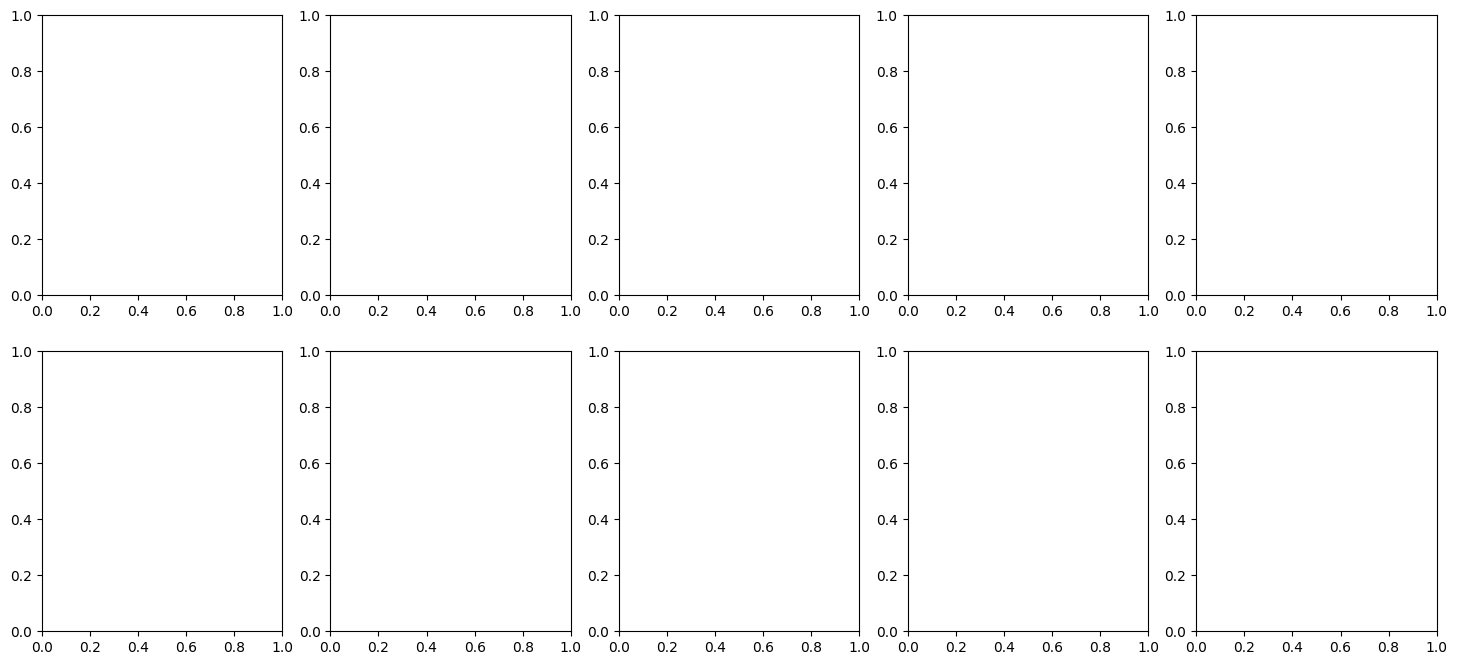

In [58]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8)
)

for ax, (_, row) in zip(
    axes.flat,
    selected_errors.iterrows()
):

    image_path = row["path"]

    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)

    ax.set_title(
        f"True: {row['true_label']}\n"
        f"Pred: {row['predicted_label']}\n"
        f"Conf: {row['confidence']:.2%}",
        fontsize=10
    )

    ax.axis("off")

plt.suptitle(
    "Representative Misclassified Test Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [59]:
import os

DATASET_ROOT = "/content/deepfake_dataset/Final Dataset"

def get_local_path(row):
    class_folder = row["true_label"]
    return os.path.join(
        DATASET_ROOT,
        class_folder,
        row["filename"]
    )

selected_errors["local_path"] = selected_errors.apply(
    get_local_path,
    axis=1
)

print(selected_errors[
    ["filename", "true_label", "predicted_label", "local_path"]
].to_string(index=False))

          filename true_label predicted_label                                                      local_path
         03853.jpg       Real            Fake          /content/deepfake_dataset/Final Dataset/Real/03853.jpg
    2LRVYKIG9Q.jpg       Fake            Real     /content/deepfake_dataset/Final Dataset/Fake/2LRVYKIG9Q.jpg
         00003.jpg       Real            Fake          /content/deepfake_dataset/Final Dataset/Real/00003.jpg
real_382_aug_2.jpg       Real            Fake /content/deepfake_dataset/Final Dataset/Real/real_382_aug_2.jpg
    0Q0WXAAJCU.jpg       Fake            Real     /content/deepfake_dataset/Final Dataset/Fake/0Q0WXAAJCU.jpg
    2OOTW565MI.jpg       Fake            Real     /content/deepfake_dataset/Final Dataset/Fake/2OOTW565MI.jpg
    3AN7SLLN7Q.jpg       Fake            Real     /content/deepfake_dataset/Final Dataset/Fake/3AN7SLLN7Q.jpg
    0KYVAIBN2A.jpg       Fake            Real     /content/deepfake_dataset/Final Dataset/Fake/0KYVAIBN2A.jpg
         0

In [60]:
selected_errors["exists"] = selected_errors["local_path"].apply(
    os.path.exists
)

print(
    selected_errors[
        ["filename", "true_label", "predicted_label", "exists"]
    ].to_string(index=False)
)

print("\nMissing images:", (~selected_errors["exists"]).sum())

          filename true_label predicted_label  exists
         03853.jpg       Real            Fake    True
    2LRVYKIG9Q.jpg       Fake            Real    True
         00003.jpg       Real            Fake    True
real_382_aug_2.jpg       Real            Fake    True
    0Q0WXAAJCU.jpg       Fake            Real    True
    2OOTW565MI.jpg       Fake            Real    True
    3AN7SLLN7Q.jpg       Fake            Real    True
    0KYVAIBN2A.jpg       Fake            Real    True
         01844.jpg       Real            Fake    True
    0REYTWJB80.jpg       Fake            Real    True

Missing images: 0


Selected images: 10
Missing images: 0


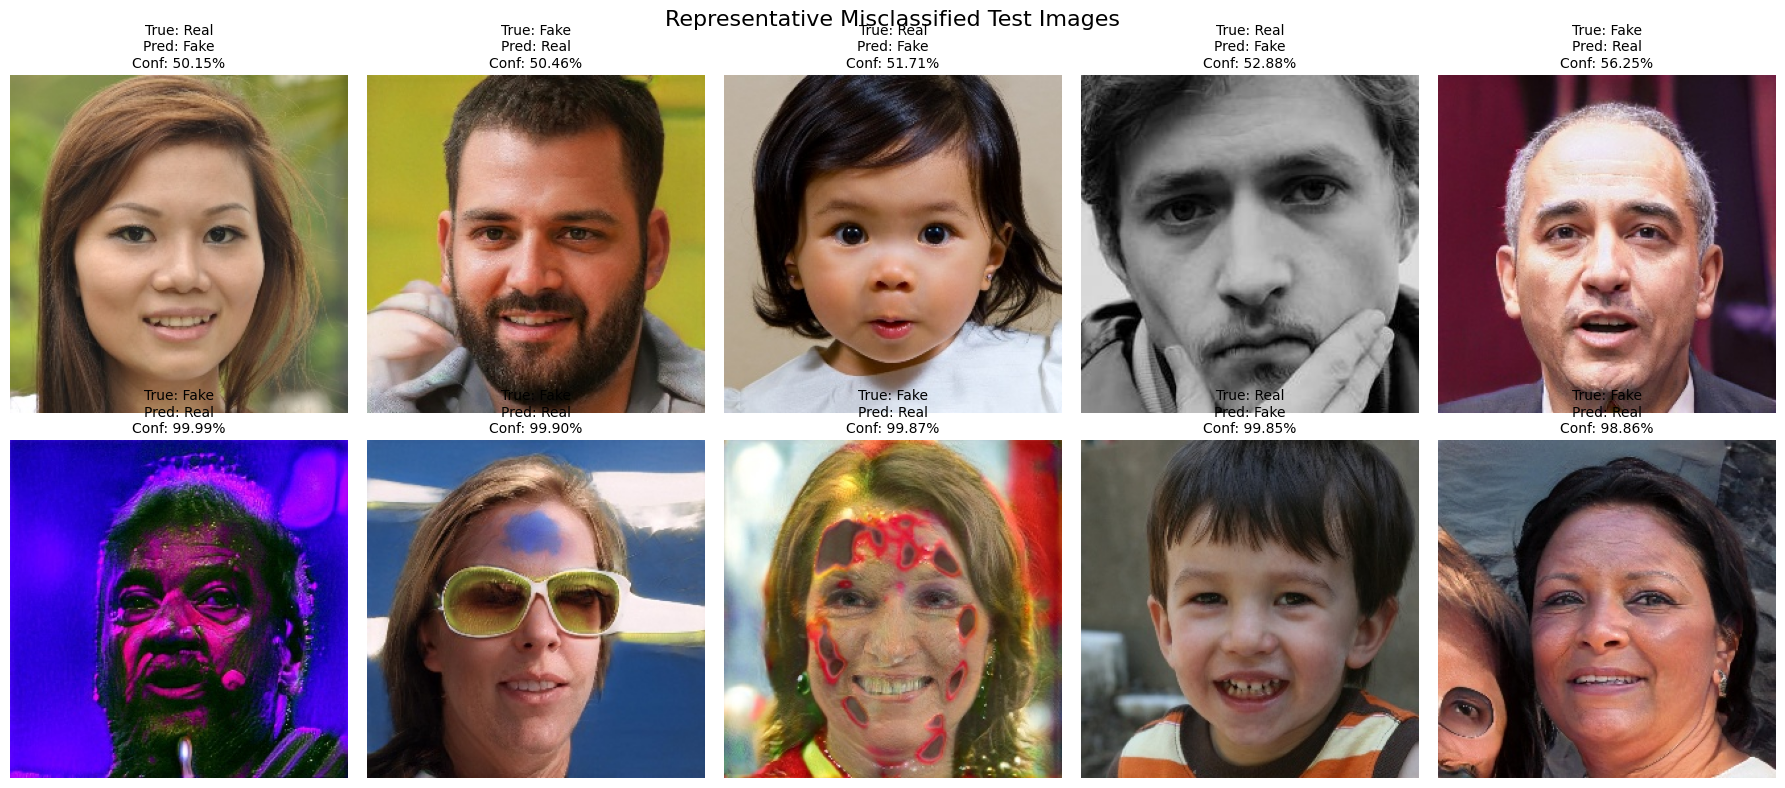

In [62]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import pandas as pd

# ==========================================
# 1. Recalculate confidence
# ==========================================

errors_display = errors.copy()

errors_display["confidence"] = errors_display[
    ["real_probability", "fake_probability"]
].max(axis=1)


# ==========================================
# 2. Select 5 most uncertain + 5 most confident
# ==========================================

uncertain_5 = errors_display.sort_values(
    "confidence",
    ascending=True
).head(5)

confident_5 = errors_display.sort_values(
    "confidence",
    ascending=False
).head(5)

selected_errors = pd.concat(
    [uncertain_5, confident_5]
).drop_duplicates(
    subset=["filename"]
).copy()


# ==========================================
# 3. Create correct local image paths
# ==========================================

DATASET_ROOT = "/content/deepfake_dataset/Final Dataset"

selected_errors["local_path"] = selected_errors.apply(
    lambda row: os.path.join(
        DATASET_ROOT,
        row["true_label"],
        row["filename"]
    ),
    axis=1
)


# ==========================================
# 4. Verify paths
# ==========================================

selected_errors["exists"] = selected_errors[
    "local_path"
].apply(os.path.exists)

print("Selected images:", len(selected_errors))
print("Missing images:", (~selected_errors["exists"]).sum())


# ==========================================
# 5. Display images
# ==========================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8)
)

for ax, (_, row) in zip(
    axes.flat,
    selected_errors.iterrows()
):

    image = Image.open(
        row["local_path"]
    ).convert("RGB")

    ax.imshow(image)

    ax.set_title(
        f"True: {row['true_label']}\n"
        f"Pred: {row['predicted_label']}\n"
        f"Conf: {row['confidence']:.2%}",
        fontsize=10
    )

    ax.axis("off")


plt.suptitle(
    "Representative Misclassified Test Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [63]:
# ==========================================
# STEP 5 — ERROR ANALYSIS BY BASE IMAGE
# ==========================================

error_groups = (
    errors
    .groupby(["base_name", "true_label"])
    .agg(
        error_count=("filename", "count"),
        filenames=("filename", list)
    )
    .reset_index()
    .sort_values(
        "error_count",
        ascending=False
    )
)

print("===== ERROR GROUPS =====")
print(
    error_groups.to_string(index=False)
)

print("\n===== SUMMARY =====")

print(
    f"Total error images          : {len(errors)}"
)

print(
    f"Unique base images involved : "
    f"{errors['base_name'].nunique()}"
)

print(
    f"Repeated-error base images  : "
    f"{(error_groups['error_count'] > 1).sum()}"
)

===== ERROR GROUPS =====
     base_name true_label  error_count                                                    filenames
   real_71.jpg       Real            3    [real_71_aug_2.jpg, real_71_aug_0.jpg, real_71_aug_3.jpg]
  real_395.jpg       Real            3 [real_395_aug_3.jpg, real_395_aug_1.jpg, real_395_aug_0.jpg]
  real_208.jpg       Real            2                     [real_208_aug_4.jpg, real_208_aug_3.jpg]
  real_352.jpg       Real            2                     [real_352_aug_3.jpg, real_352_aug_0.jpg]
     00003.jpg       Real            1                                                  [00003.jpg]
     01567.jpg       Real            1                                                  [01567.jpg]
     01430.jpg       Real            1                                                  [01430.jpg]
     01184.jpg       Real            1                                                  [01184.jpg]
     00123.jpg       Real            1                                     

In [64]:
# ==========================================
# STEP 6 — ORIGINAL VS AUGMENTED ERRORS
# ==========================================

# Identify augmented images using the filename pattern
test_results["is_augmented"] = test_results["filename"].str.contains(
    r"_aug_\d+",
    regex=True
)

# -----------------------------
# Overall test-set distribution
# -----------------------------

test_distribution = (
    test_results["is_augmented"]
    .value_counts()
    .rename(index={
        False: "Original",
        True: "Augmented"
    })
)

# -----------------------------
# Error distribution
# -----------------------------

error_distribution = (
    test_results[
        test_results["correct"] == False
    ]["is_augmented"]
    .value_counts()
    .rename(index={
        False: "Original",
        True: "Augmented"
    })
)

print("===== TEST SET DISTRIBUTION =====")

print(test_distribution)

print("\n===== ERROR DISTRIBUTION =====")

print(error_distribution)


# -----------------------------
# Calculate error rates
# -----------------------------

summary = []

for is_aug, name in [
    (False, "Original"),
    (True, "Augmented")
]:

    total = (
        test_results["is_augmented"] == is_aug
    ).sum()

    errors_count = (
        (test_results["is_augmented"] == is_aug) &
        (test_results["correct"] == False)
    ).sum()

    error_rate = errors_count / total

    summary.append({
        "Type": name,
        "Total Test Images": total,
        "Errors": errors_count,
        "Error Rate": error_rate
    })

summary_df = pd.DataFrame(summary)

print("\n===== ERROR RATE =====")

print(
    summary_df.to_string(
        index=False,
        formatters={
            "Error Rate": "{:.4%}".format
        }
    )
)

===== TEST SET DISTRIBUTION =====
is_augmented
Original     975
Augmented    930
Name: count, dtype: int64

===== ERROR DISTRIBUTION =====
is_augmented
Original     29
Augmented    14
Name: count, dtype: int64

===== ERROR RATE =====
     Type  Total Test Images  Errors Error Rate
 Original                975      29    2.9744%
Augmented                930      14    1.5054%


In [65]:
# ==========================================
# STEP 7 — ERROR RATE BY CLASS + IMAGE TYPE
# ==========================================

class_aug_summary = []

for label in ["Real", "Fake"]:

    for is_aug, image_type in [
        (False, "Original"),
        (True, "Augmented")
    ]:

        subset = test_results[
            (test_results["true_label"] == label) &
            (test_results["is_augmented"] == is_aug)
        ]

        total = len(subset)

        errors_count = (
            subset["correct"] == False
        ).sum()

        error_rate = (
            errors_count / total
            if total > 0
            else 0
        )

        class_aug_summary.append({
            "True Class": label,
            "Image Type": image_type,
            "Total": total,
            "Errors": errors_count,
            "Error Rate": error_rate
        })

class_aug_df = pd.DataFrame(
    class_aug_summary
)

print(
    class_aug_df.to_string(
        index=False,
        formatters={
            "Error Rate": "{:.4%}".format
        }
    )
)

True Class Image Type  Total  Errors Error Rate
      Real   Original    439      11    2.5057%
      Real  Augmented    460      13    2.8261%
      Fake   Original    536      18    3.3582%
      Fake  Augmented    470       1    0.2128%


In [66]:
baseline_results = {
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1,
    "ROC-AUC": test_auc
}

print(baseline_results)

{'Accuracy': 0.9774278215223097, 'Precision': 0.9762611275964391, 'Recall': 0.9811133200795229, 'F1': 0.9786812097174021, 'ROC-AUC': np.float64(0.9970731782829165)}


In [67]:
from PIL import Image
import io
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_jpeg_compression(quality=50):

    model.eval()

    labels = []
    predictions = []
    probabilities = []

    with torch.no_grad():

        for images, batch_labels in test_loader:

            compressed_images = []

            # Convert each normalized tensor back to a PIL image
            for image_tensor in images:

                # Undo ImageNet normalization
                image_tensor = image_tensor.clone()

                mean = torch.tensor(
                    [0.485, 0.456, 0.406]
                ).view(3, 1, 1)

                std = torch.tensor(
                    [0.229, 0.224, 0.225]
                ).view(3, 1, 1)

                image_tensor = (
                    image_tensor * std + mean
                ).clamp(0, 1)

                image_array = (
                    image_tensor
                    .permute(1, 2, 0)
                    .numpy() * 255
                ).astype(np.uint8)

                pil_image = Image.fromarray(
                    image_array
                )

                # JPEG compression in memory
                buffer = io.BytesIO()

                pil_image.save(
                    buffer,
                    format="JPEG",
                    quality=quality
                )

                buffer.seek(0)

                compressed_image = Image.open(
                    buffer
                ).convert("RGB")

                compressed_images.append(
                    eval_transform(compressed_image)
                )

            compressed_batch = torch.stack(
                compressed_images
            ).to(
                device,
                non_blocking=True
            )

            batch_labels = batch_labels.to(
                device,
                non_blocking=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(
                    compressed_batch
                )

            probs = torch.softmax(
                outputs,
                dim=1
            )

            preds = torch.argmax(
                outputs,
                dim=1
            )

            labels.extend(
                batch_labels.cpu().numpy()
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            probabilities.extend(
                probs[:, 1]
                .float()
                .cpu()
                .numpy()
            )

    return {
        "Accuracy": accuracy_score(
            labels,
            predictions
        ),

        "Precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            labels,
            predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            labels,
            probabilities
        )
    }


jpeg_50_results = evaluate_jpeg_compression(
    quality=50
)

print("===== JPEG QUALITY 50 =====")

for metric, value in jpeg_50_results.items():
    print(f"{metric}: {value:.4f}")

===== JPEG QUALITY 50 =====
Accuracy: 0.7753
Precision: 0.7021
Recall: 0.9980
F1: 0.8243
ROC-AUC: 0.8781


In [68]:
jpeg_80_results = evaluate_jpeg_compression(
    quality=80
)

print("===== JPEG QUALITY 80 =====")

for metric, value in jpeg_80_results.items():
    print(f"{metric}: {value:.4f}")

===== JPEG QUALITY 80 =====
Accuracy: 0.7900
Precision: 0.7158
Recall: 0.9990
F1: 0.8340
ROC-AUC: 0.9207


In [69]:
import pandas as pd

robustness_results = pd.DataFrame([
    baseline_results,
    jpeg_80_results,
    jpeg_50_results
], index=[
    "Original",
    "JPEG Q80",
    "JPEG Q50"
])

print("===== ROBUSTNESS COMPARISON =====")
display(robustness_results.round(4))

===== ROBUSTNESS COMPARISON =====


,Accuracy,Precision,Recall,F1,ROC-AUC
Original,0.9774,0.9763,0.9811,0.9787,0.9971
JPEG Q80,0.7900,0.7158,0.9990,0.8340,0.9207
JPEG Q50,0.7753,0.7021,0.9980,0.8243,0.8781


In [70]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the same EfficientNet-B0 architecture
model = efficientnet_b0(weights=None)

# Same classifier used during training
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

# Checkpoint path
checkpoint_path = "/content/drive/MyDrive/Deepfake_Detection/best_efficientnet_b0.pth"

# Load checkpoint
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

# Load ONLY the trained model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Move model to device
model = model.to(device)

# Evaluation mode
model.eval()

print("Model loaded successfully!")
print("Device:", device)
print("Architecture: EfficientNet-B0")
print("Classes: Real (0), Fake (1)")
print("Best Epoch:", checkpoint["epoch"] + 1)
print("Validation Loss:", checkpoint["val_loss"])
print("Validation Accuracy:", checkpoint["val_accuracy"])
print("Validation F1:", checkpoint["val_f1"])

Model loaded successfully!
Device: cuda
Architecture: EfficientNet-B0
Classes: Real (0), Fake (1)
Best Epoch: 11
Validation Loss: 0.07798875198552482
Validation Accuracy: 0.9794736842105263
Validation F1: 0.9807597434632461


In [71]:
from torchvision import transforms

# Same preprocessing used for validation and test
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Inference transform ready!")

Inference transform ready!


In [72]:
from PIL import Image
import torch

def predict_image(image_path):
    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    image_tensor = inference_transform(image)

    # Add batch dimension: [3, 224, 224] -> [1, 3, 224, 224]
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(image_tensor)

        probabilities = torch.softmax(outputs, dim=1)

    # Extract probabilities
    real_probability = probabilities[0, 0].item()
    fake_probability = probabilities[0, 1].item()

    # Prediction
    predicted_class = torch.argmax(probabilities, dim=1).item()

    label = "Fake" if predicted_class == 1 else "Real"

    return {
        "prediction": label,
        "real_probability": real_probability,
        "fake_probability": fake_probability
    }

print("Prediction function ready!")

Prediction function ready!


In [73]:
# Pick the first image from the held-out test set
test_sample = test_df.iloc[0]

# Convert the dataset path to the actual local path
relative_path = test_sample["path"].split("Final Dataset/")[-1]
test_image_path = f"/content/deepfake_dataset/Final Dataset/{relative_path}"

# Run prediction
result = predict_image(test_image_path)

print("===== INFERENCE TEST =====")
print("Image:", test_sample["filename"])
print("Actual Label:", test_sample["label"])
print("Predicted Label:", result["prediction"])
print(f"Real Probability : {result['real_probability']:.4%}")
print(f"Fake Probability : {result['fake_probability']:.4%}")

===== INFERENCE TEST =====
Image: 2TSVE42PCX.jpg
Actual Label: Fake
Predicted Label: Fake
Real Probability : 0.0043%
Fake Probability : 100.0000%


In [74]:
def predict_image_detailed(image_path):
    result = predict_image(image_path)

    prediction = result["prediction"]

    if prediction == "Fake":
        confidence = result["fake_probability"]
    else:
        confidence = result["real_probability"]

    return {
        "prediction": prediction,
        "confidence": confidence,
        "real_probability": result["real_probability"],
        "fake_probability": result["fake_probability"]
    }

print("Detailed prediction function ready!")

Detailed prediction function ready!


In [75]:
result = predict_image_detailed(test_image_path)

print("===== DEEPFAKE DETECTION =====")
print(f"Prediction : {result['prediction'].upper()}")
print(f"Confidence : {result['confidence']:.2%}")
print()
print(f"Real Probability : {result['real_probability']:.2%}")
print(f"Fake Probability : {result['fake_probability']:.2%}")

===== DEEPFAKE DETECTION =====
Prediction : FAKE
Confidence : 100.00%

Real Probability : 0.00%
Fake Probability : 100.00%


In [76]:
print("===== FINAL MODEL METRICS (TEST SET) =====")
for metric, value in baseline_results.items():
    print(f"{metric:12s} : {value*100:.2f} %")

print("\n===== PERFORMANCE UNDER COMPRESSION =====")
display(robustness_results.round(4))


===== FINAL MODEL METRICS (TEST SET) =====
Accuracy     : 97.74 %
Precision    : 97.63 %
Recall       : 98.11 %
F1           : 97.87 %
ROC-AUC      : 99.71 %

===== PERFORMANCE UNDER COMPRESSION =====


,Accuracy,Precision,Recall,F1,ROC-AUC
Original,0.9774,0.9763,0.9811,0.9787,0.9971
JPEG Q80,0.7900,0.7158,0.9990,0.8340,0.9207
JPEG Q50,0.7753,0.7021,0.9980,0.8243,0.8781


In [77]:
import os

project_dir = "/content/Deepfake_Detection_Project"

os.makedirs(project_dir, exist_ok=True)

print("Project directory created:")
print(project_dir)

Project directory created:
/content/Deepfake_Detection_Project


In [78]:
app_code = r'''
import streamlit as st
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0
from torchvision import transforms
from PIL import Image


# =========================
# Configuration
# =========================

MODEL_PATH = "model/best_efficientnet_b0.pth"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# =========================
# Image Preprocessing
# =========================

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# =========================
# Load Model
# =========================

@st.cache_resource
def load_model():

    model = efficientnet_b0(weights=None)

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        2
    )

    checkpoint = torch.load(
        MODEL_PATH,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model = model.to(device)
    model.eval()

    return model


model = load_model()


# =========================
# Prediction
# =========================

def predict_image(image):

    image = image.convert("RGB")

    image_tensor = inference_transform(image)

    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        if device.type == "cuda":

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):
                outputs = model(image_tensor)

        else:
            outputs = model(image_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

    real_probability = probabilities[0, 0].item()
    fake_probability = probabilities[0, 1].item()

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()

    prediction = (
        "Fake"
        if predicted_class == 1
        else "Real"
    )

    confidence = (
        fake_probability
        if prediction == "Fake"
        else real_probability
    )

    return (
        prediction,
        confidence,
        real_probability,
        fake_probability
    )


# =========================
# Streamlit Interface
# =========================

st.title("Deepfake Image Detector")

st.write(
    "Upload a face image to classify it as "
    "Real or Fake."
)

uploaded_file = st.file_uploader(
    "Upload an image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:

    image = Image.open(uploaded_file)

    st.image(
        image,
        caption="Uploaded Image",
        use_container_width=True
    )

    if st.button("Analyze Image"):

        prediction, confidence, real_probability, fake_probability = predict_image(
            image
        )

        st.subheader(
            f"Prediction: {prediction.upper()}"
        )

        st.write(
            f"Confidence: {confidence:.2%}"
        )

        st.write(
            f"Real Probability: {real_probability:.2%}"
        )

        st.write(
            f"Fake Probability: {fake_probability:.2%}"
        )
'''

app_path = "/content/Deepfake_Detection_Project/app.py"

with open(app_path, "w") as f:
    f.write(app_code)

print("app.py created successfully!")
print(app_path)

app.py created successfully!
/content/Deepfake_Detection_Project/app.py


In [79]:
import os
import shutil

# Create model directory
model_dir = "/content/Deepfake_Detection_Project/model"
os.makedirs(model_dir, exist_ok=True)

# Source checkpoint
source_model = "/content/drive/MyDrive/Deepfake_Detection/best_efficientnet_b0.pth"

# Destination
destination_model = os.path.join(
    model_dir,
    "best_efficientnet_b0.pth"
)

# Copy checkpoint
shutil.copy2(source_model, destination_model)

print("Model copied successfully!")
print("Destination:", destination_model)

# Verify file
print("File exists:", os.path.exists(destination_model))
print(
    f"File size: {os.path.getsize(destination_model) / (1024**2):.2f} MB"
)

Model copied successfully!
Destination: /content/Deepfake_Detection_Project/model/best_efficientnet_b0.pth
File exists: True
File size: 46.36 MB


In [80]:
import os

project_dir = "/content/Deepfake_Detection_Project"

print("===== PROJECT STRUCTURE =====")

for root, dirs, files in os.walk(project_dir):
    level = root.replace(project_dir, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

===== PROJECT STRUCTURE =====
Deepfake_Detection_Project/
    app.py
    model/
        best_efficientnet_b0.pth


In [81]:
requirements = """streamlit
torch
torchvision
pillow
"""

requirements_path = "/content/Deepfake_Detection_Project/requirements.txt"

with open(requirements_path, "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")
print()
print(requirements)

requirements.txt created successfully!

streamlit
torch
torchvision
pillow



In [82]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 50.0 MB/s eta 0:00:00


In [83]:
import subprocess
import time

project_dir = "/content/Deepfake_Detection_Project"

# Start Streamlit
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port=8501",
        "--server.address=0.0.0.0"
    ],
    cwd=project_dir,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("Streamlit process started!")
print("PID:", process.pid)

Streamlit process started!
PID: 4068


In [84]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [85]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [86]:
import requests

try:
    response = requests.get("http://127.0.0.1:8501", timeout=10)

    print("Status code:", response.status_code)
    print("Streamlit server is responding:", response.ok)

except Exception as e:
    print("Streamlit server is NOT responding.")
    print("Error:", e)

Status code: 200
Streamlit server is responding: True


In [88]:
import subprocess
import time

# Stop the old Streamlit process
process.terminate()

try:
    process.wait(timeout=5)
except:
    process.kill()

# Restart Streamlit with Colab-compatible settings
project_dir = "/content/Deepfake_Detection_Project"

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port=8501",
        "--server.address=0.0.0.0",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false"
    ],
    cwd=project_dir,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("Streamlit restarted!")
print("PID:", process.pid)

Streamlit restarted!
PID: 6048


In [90]:
print("===== STREAMLIT LOG =====")

while True:
    line = process.stdout.readline()

    if not line:
        break

    print(line, end="")

===== STREAMLIT LOG =====
  Stopping...


In [91]:
import os

project_dir = "/content/Deepfake_Detection_Project"

folders = [
    "model",
    "notebooks",
    "results"
]

for folder in folders:
    os.makedirs(os.path.join(project_dir, folder), exist_ok=True)

print("Final project folders ready:")
print()

for root, dirs, files in os.walk(project_dir):
    level = root.replace(project_dir, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}    {file}")

Final project folders ready:

Deepfake_Detection_Project/
    app.py
    requirements.txt
    results/
    notebooks/
    model/
        best_efficientnet_b0.pth
